## AI Boom vs. Dot-Com Bust: A Statistical Autopsy of Two Market Manias
*Part 1 of a series on market bubbles and long-term investing.*

I'm looking at the S&P 500 specifically because it's what I'm invested in - through this index and other funds - so I'm curious what my money can realistically expect going forward. Will I gain a lot, lose a lot in an AI bubble, or land somewhere in between?

I've seen plenty of people analyze and comment on the S&P 500 and the AI bubble question, but I wanted to see it for myself - through the data and my own analysis, rather than taking anyone else's word for it. The goal here isn't to settle whether an AI bubble exists - plenty of people are already arguing that quesmtion. It's to look at what the data actually says, regardless of which side turns out to be right.

**TL;DR (this is a long one):**
- **Similar shape, different mechanics:** once shifted ~132 trading days, the AI rally's price trajectory correlates 0.985 with the dot-com bubble - but day-to-day log returns barely correlate at all (-0.029), so the two booms aren't actually moving for the same reasons.
- **Calmer overall, but fatter tails:** the AI era has lower day-to-day volatility than dot-com's run-up, but far more extreme outlier days (kurtosis 13.3 vs 3.5) - a "quiet market punctuated by earthquakes" instead of dot-com's sustained nervousness.
- **Similar drawdowns and recovery speed:** despite the different tail behavior, the worst pullback-while-climbing and the time to recover from it are nearly identical between the two eras so far.
- **Every 12-month holding period in the AI era so far has stayed positive** - dot-com's eventually didn't, once its crash entered the rolling window.
- **Bottom line:** the two bubbles rhyme in shape but not in behavior. More parts in this series will dig into whether any of this actually matters if you just hold for the long run.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from datetime import date, timedelta

# Fixed end date for all "through present" downloads, so results/labels stay stable on re-run
END_DATE = (date.today() - timedelta(days=1)).isoformat()

### Dot-com vs AI boom bobble study

##### Shape & volatility comparison

In [2]:
# Dot-com era
ticker = "^GSPC"
dotcom = yf.download(
    ticker,
    start="1997-01-01",
    end="2002-12-31",
    auto_adjust=True
)

# the current AI boom
ticker = "^GSPC"

ai = yf.download(
    ticker,
    start="2023-01-01",
    end=END_DATE,  # fixed end date so results/labels don't shift every time this is re-run
    auto_adjust=True
)

# Reuse the dot-com era data already downloaded above
dotcom_norm = dotcom["Close"] / dotcom["Close"].iloc[0] * 100
ai_norm = ai["Close"] / ai["Close"].iloc[0] * 100

# Sanity check the downloaded data
print("Dot-com era sample:")
print(dotcom_norm.tail())

print("AI era sample:")
print(ai_norm.tail(5))

Cookie fetch from fc.yahoo.com failed (CertificateVerifyError), continuing without it
Cookie/crumb fetch failed (CertificateVerifyError), continuing without crumb
[*********************100%***********************]  1 of 1 completed
Cookie/crumb fetch failed (CertificateVerifyError), continuing without crumb
[*********************100%***********************]  1 of 1 completed

Dot-com era sample:
Ticker           ^GSPC
Date                  
2002-12-23  121.759541
2002-12-24  121.093331
2002-12-26  120.712061
2002-12-27  118.777223
2002-12-30  119.318599
AI era sample:
Ticker           ^GSPC
Date                  
2026-09-08  200.660024
2026-09-09  199.688298
2026-09-10  198.520462
2026-09-11  200.227507
2026-09-14  199.259969


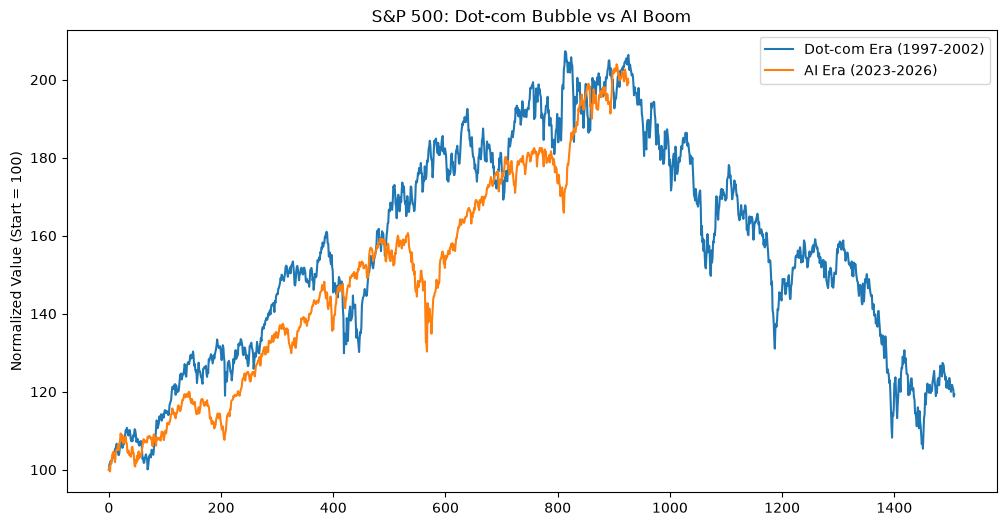

In [3]:
# Plot both eras on the same axis (trading days since start) to compare shape, not calendar time
plt.figure(figsize=(12,6))

plt.plot(dotcom_norm.values, label="Dot-com Era (1997-2002)")
plt.plot(ai_norm.values, label=f"AI Era (2023-{ai.index[-1].year})")

plt.ylabel("Normalized Value (Start = 100)")
plt.title("S&P 500: Dot-com Bubble vs AI Boom")
plt.legend()
plt.show()

In [4]:
# Trim dot-com era to the same number of trading days as the AI era for a fair comparison
n = len(ai_norm)
dotcom_matched = dotcom_norm.iloc[:n]
ai_matched = ai_norm.iloc[:n]

# Daily returns from the normalized series
dotcom_returns = dotcom_matched.pct_change().dropna()
ai_returns = ai_matched.pct_change().dropna()

# Annualized volatility (std of daily returns scaled to a 252-trading-day year)
dotcom_volatility = dotcom_returns.std() * np.sqrt(252)
ai_volatility = ai_returns.std() * np.sqrt(252)

print(f"Dot-com volatility (annualized, first {n} trading days): {dotcom_volatility.iloc[0]:.2%}")
print(f"AI boom volatility (annualized, first {n} trading days): {ai_volatility.iloc[0]:.2%}")

Dot-com volatility (annualized, first 927 trading days): 19.52%
AI boom volatility (annualized, first 927 trading days): 14.75%


**Shape & volatility takeaway (matched to the AI era's history so far):**
- **Similar overall shape:** both eras show the same steady melt-up trajectory once normalized to a common starting value.
- **AI boom is less volatile:** annualized volatility is 14.75% for the AI era vs. 19.52% for dot-com — a calmer climb so far, at least by this measure.


#### Curve Alignment & Correlation

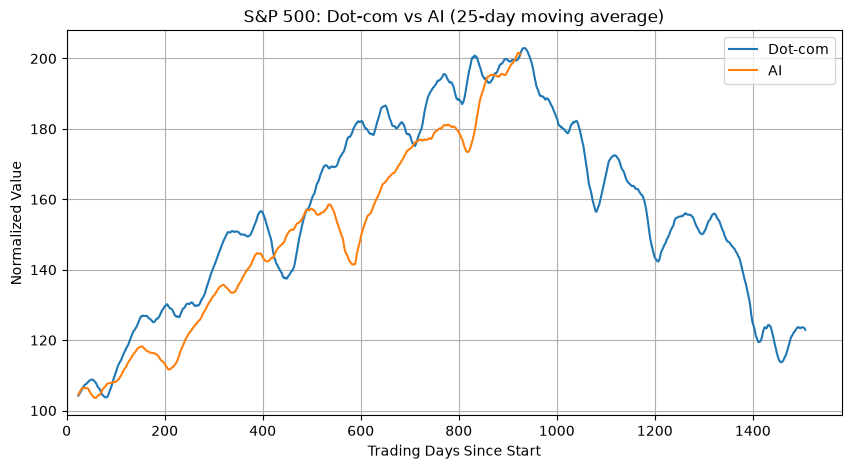

In [5]:
# Smooth out day-to-day noise with a short moving average
rolling_window = 25
dotcom_smooth = dotcom_norm.rolling(rolling_window).mean()
ai_smooth = ai_norm.rolling(rolling_window).mean()

# No shift applied yet - just overlaying the two curves as-is
shift = 0
x_ai_shifted = np.arange(len(ai_smooth)) - shift

plt.figure(figsize=(10, 5))

plt.plot(dotcom_smooth.values, label="Dot-com")
plt.plot(x_ai_shifted, ai_smooth.values, label="AI")

plt.title("S&P 500: Dot-com vs AI (25-day moving average)")
plt.ylabel("Normalized Value")
plt.xlabel("Trading Days Since Start")
plt.legend()
plt.grid(True)
plt.xlim(left=0)

plt.show()


The two curves look similar in shape - let's try shifting the AI curve to see if they align even more closely.

In [6]:
# Automatically find the shift (in trading days) that maximizes correlation between the two smoothed curves,
# instead of picking it by eye
dotcom_smooth = dotcom_norm.rolling(rolling_window).mean().dropna()
ai_smooth = ai_norm.rolling(rolling_window).mean().dropna()

max_shift = min(len(dotcom_smooth), len(ai_smooth)) - 50  # keep enough overlap for a meaningful correlation
shifts = range(0, max_shift)
correlations = []

for s in shifts:
    ai_shifted = ai_smooth.iloc[s:].reset_index(drop=True)
    dotcom_comparison = dotcom_smooth.iloc[:len(ai_shifted)].reset_index(drop=True)
    c = np.corrcoef(dotcom_comparison.to_numpy().ravel(), ai_shifted.to_numpy().ravel())[0, 1]
    correlations.append(c)

shift = shifts[int(np.argmax(correlations))]
print(f"Best shift: {shift} trading days (correlation = {max(correlations):.3f})")

Best shift: 132 trading days (correlation = 0.985)


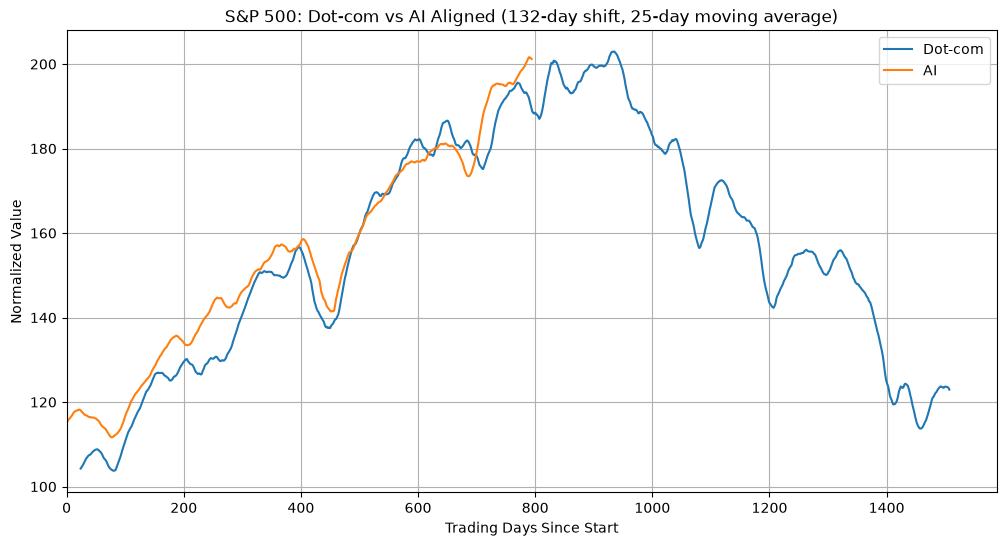

In [7]:
# Smooth out day-to-day noise with a short moving average
rolling_window = 25
dotcom_smooth = dotcom_norm.rolling(rolling_window).mean()
ai_smooth = ai_norm.rolling(rolling_window).mean()

# Shift found automatically above (maximizes correlation) instead of a manually chosen value
x_ai_shifted = np.arange(len(ai_smooth)) - shift

plt.figure(figsize=(12, 6))

plt.plot(dotcom_smooth.values, label="Dot-com")
plt.plot(x_ai_shifted, ai_smooth.values, label="AI")

plt.title(f"S&P 500: Dot-com vs AI Aligned ({shift}-day shift, 25-day moving average)")
plt.ylabel("Normalized Value")
plt.xlabel("Trading Days Since Start")
plt.legend()
plt.grid(True)
plt.xlim(left=0)

plt.show()

So high correlation (0.985)! Is it just a coincidence or does it indicate a similar pattern in the two bubbles?

#### Log Returns: Day-to-Day Dynamics

In [8]:
# Log return = ln(P_t / P_t-1), i.e. day-over-day % change with the trend removed - lets us compare dynamics, not just direction
dotcom_log_returns = np.diff(np.log(dotcom_norm.squeeze().dropna())) * 100  # in percentage
ai_log_returns = np.diff(np.log(ai_norm.squeeze().dropna())) * 100  # in percentage

# Apply the same automatically found shift alignment
ai_log_returns_shifted = ai_log_returns[shift:]
dotcom_log_returns_aligned = dotcom_log_returns[:len(ai_log_returns_shifted)]

# Calculate correlation of log returns
log_returns_corr = np.corrcoef(dotcom_log_returns_aligned, ai_log_returns_shifted)[0, 1]
# Price-level correlation at the best shift, computed earlier in the auto-shift search
corr = max(correlations)
# A cleaner test of whether the two bubbles actually move similarly day-to-day, vs. just both trending upward
print(f"Log returns correlation (with {shift}-day shift): {log_returns_corr:.3f}")
print(f"Price level correlation (with {shift}-day shift): {corr:.3f}")
print(f"\nDifference: {abs(log_returns_corr - corr):.3f}")


Log returns correlation (with 132-day shift): -0.029
Price level correlation (with 132-day shift): 0.985

Difference: 1.014


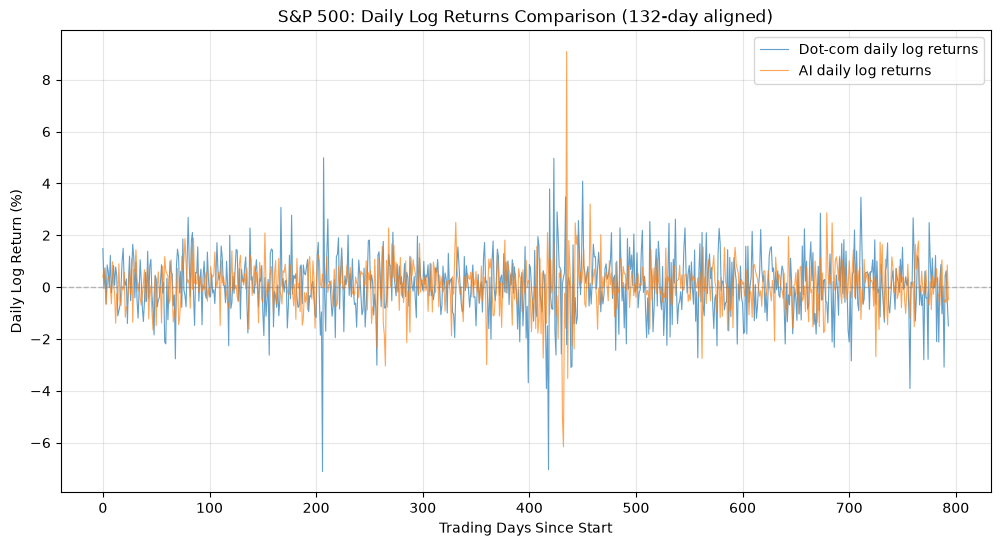

In [19]:
# Visualize log returns patterns
plt.figure(figsize=(12, 6))

plt.plot(dotcom_log_returns_aligned, label="Dot-com daily log returns", alpha=0.7, linewidth=0.8)
plt.plot(ai_log_returns_shifted, label="AI daily log returns", alpha=0.7, linewidth=0.8)

plt.axhline(0, color="gray", linewidth=1, linestyle="--", alpha=0.5)
plt.title(f"S&P 500: Daily Log Returns Comparison ({shift}-day aligned)")
plt.ylabel("Daily Log Return (%)")
plt.xlabel("Trading Days Since Start")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

**Key insight:** High price-level correlation (0.985) but near-zero log-returns correlation (-0.029) suggests:
- **Similar shapes, different dynamics:** The trajectory matches, but day-to-day growth rates diverge completely.
- **Structural vs. behavioral:** The high price-level correlation (0.985) mainly reflects a similar overall shape once aligned (structural). The near-zero log-returns correlation (-0.029) shows daily moves aren't linked - so investors aren't reacting to the same triggers day-to-day (no shared behavioral pattern).

#### Return Distribution & Volatility Dynamics (Pre-Crash Run-Up)

In [10]:
# Distribution statistics comparison (only up to dot-com's peak, excluding the crash)
from scipy.stats import skew, kurtosis

# Find the trading day where the dot-com era hit its all-time high (pre-crash)
dotcom_peak_idx = int(np.argmax(dotcom_norm.to_numpy()))

# Use equal length for fair comparison - up to the dot-com peak (or AI's available days, whichever is shorter)
n_days = min(dotcom_peak_idx, len(ai_log_returns))
limited_by_ai = len(ai_log_returns) < dotcom_peak_idx
dotcom_log_returns_equal = dotcom_log_returns[:n_days]
ai_log_returns_equal = ai_log_returns[:n_days]

dotcom_stats = {
    'Mean Daily Return (%)': np.mean(dotcom_log_returns_equal),
    'Std Dev (%)': np.std(dotcom_log_returns_equal),
    'Skewness': skew(dotcom_log_returns_equal),
    'Kurtosis': kurtosis(dotcom_log_returns_equal),
    'Min Daily Return (%)': np.min(dotcom_log_returns_equal),
    'Max Daily Return (%)': np.max(dotcom_log_returns_equal),
}

ai_stats = {
    'Mean Daily Return (%)': np.mean(ai_log_returns_equal),
    'Std Dev (%)': np.std(ai_log_returns_equal),
    'Skewness': skew(ai_log_returns_equal),
    'Kurtosis': kurtosis(ai_log_returns_equal),
    'Min Daily Return (%)': np.min(ai_log_returns_equal),
    'Max Daily Return (%)': np.max(ai_log_returns_equal),
}

print("DYNAMICS COMPARISON: Dot-com (pre-crash, up to its peak) vs AI")
print(f"Dot-com peak so far: day {dotcom_peak_idx} | AI era so far: {len(ai_log_returns)} trading days")
if limited_by_ai:
    print(f"NOTE: window capped at {n_days} days by the AI era's shorter history - dot-com has NOT yet reached its peak in this comparison.\n")
else:
    print(f"Window covers the full dot-com run-up to its peak ({n_days} days); AI has more history available beyond this window.\n")

print(f"Dot-com Era (first {n_days} trading days):")
for stat, value in dotcom_stats.items():
    print(f"  {stat}: {value:.3f}")

print(f"\nAI Era (first {n_days} trading days):")
for stat, value in ai_stats.items():
    print(f"  {stat}: {value:.3f}")

print("\nDifferences (AI - Dot-com):")
for stat in dotcom_stats.keys():
    diff = ai_stats[stat] - dotcom_stats[stat]
    print(f"  {stat}: {diff:+.3f}")

DYNAMICS COMPARISON: Dot-com (pre-crash, up to its peak) vs AI
Dot-com peak so far: day 814 | AI era so far: 926 trading days
Window covers the full dot-com run-up to its peak (814 days); AI has more history available beyond this window.

Dot-com Era (first 814 trading days):
  Mean Daily Return (%): 0.090
  Std Dev (%): 1.220
  Skewness: -0.386
  Kurtosis: 3.515
  Min Daily Return (%): -7.113
  Max Daily Return (%): 4.989

AI Era (first 814 trading days):
  Mean Daily Return (%): 0.067
  Std Dev (%): 0.943
  Skewness: 0.320
  Kurtosis: 13.307
  Min Daily Return (%): -6.161
  Max Daily Return (%): 9.089

Differences (AI - Dot-com):
  Mean Daily Return (%): -0.023
  Std Dev (%): -0.277
  Skewness: +0.706
  Kurtosis: +9.791
  Min Daily Return (%): +0.952
  Max Daily Return (%): +4.101


**Stats conclusion (dot-com pre-crash run vs AI, first 814 trading days each):**
- **Mean daily return is slightly higher for dot-com** (0.090% vs 0.067%) — excluding the crash, dot-com actually grew a bit faster on average during its pure run-up.
- **AI is less volatile overall** (Std Dev 0.943 vs 1.220) — smoother day-to-day moves even during its most euphoric phase.
- **Skewness flips sign** (Dot-com -0.386 vs AI +0.320) — even in its pre-crash run, dot-com already leaned toward sharp down-day pullbacks, while AI leans toward sharp up-day rallies.
- **AI has much fatter tails** (Kurtosis 13.307 vs 3.515) — extreme moves are far more frequent and less predictable in the AI era, even when only comparing the run-up phase.
- **Net picture:** isolating dot-com's pure bull run (no crash) still shows the same core difference — dot-com's climb was already down-tail heavy and closer to normal volatility, while AI's climb is up-tail heavy with occasional violent spikes in both directions.
- **Analogy:** two cities growing at the same rate, but AI has random earthquakes (fat tails, unpredictable extreme moves) while dot-com has predictable seasonal shifts (normal tails, more typical volatility) — and this holds even before dot-com's crash begins.


**What the structural difference actually is:**
- **Volatility clustering pattern:** Dot-com's kurtosis (~3.5) is close to a normal distribution — daily swings are fairly consistent in size. AI's kurtosis (~13.3) means most days are calm but occasionally jolt with huge, rare moves — typical of a market driven by discrete shock events (earnings surprises, single-stock mega-cap moves, AI-specific news) rather than steady, broad-based buying.
- **Direction of extreme days:** Dot-com's negative skew means bad days were more extreme than good days — a market already nervous/fragile even while trending up. AI's positive skew means good days are more extreme than bad days — consistent with melt-up/FOMO buying, where rallies are punctuated by outsized up-moves.
- **Concentration vs. breadth:** AI's fat tails plus lower overall volatility suggest the rally is more narrow/concentrated — a small number of days (and likely a small number of mega-cap stocks) driving most of the movement, with unusually quiet periods in between. Dot-com's more "normal" distribution suggests broader, more continuous participation across many stocks/days.
- **In short:** dot-com's bull run was broad and persistently nervous; the AI rally is quiet and concentrated, punctuated by occasional violent up-moves — likely reflecting a market driven by a handful of mega-cap AI stocks/news events rather than broad speculative participation.


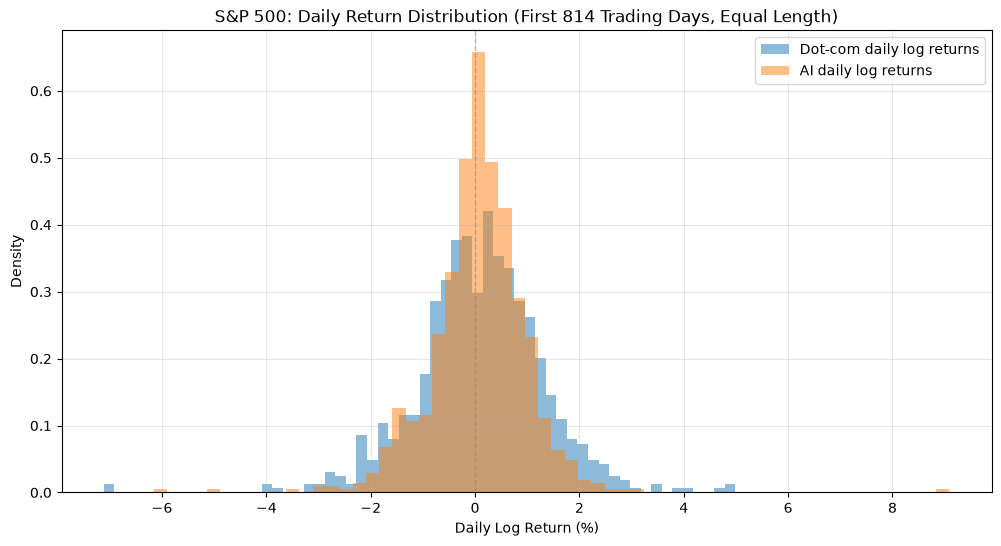

In [11]:
# Overlay the daily log-return distributions (same equal-length pre-crash window used above)
plt.figure(figsize=(12, 6))

plt.hist(dotcom_log_returns_equal, bins=60, alpha=0.5, density=True, label="Dot-com daily log returns")
plt.hist(ai_log_returns_equal, bins=60, alpha=0.5, density=True, label="AI daily log returns")

plt.axvline(0, color="gray", linewidth=1, linestyle="--", alpha=0.5)
plt.title(f"S&P 500: Daily Return Distribution (First {n_days} Trading Days, Equal Length)")
plt.xlabel("Daily Log Return (%)")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


**Takeaway:** The histogram makes the skew/kurtosis numbers visible - AI's distribution (orange) is taller and narrower in the middle (lower volatility, higher kurtosis), with a visible outlier on the far right (~+9%), while dot-com's (blue) is wider/flatter with a visible outlier on the far left (~-7%), matching its negative skew vs AI's positive skew.

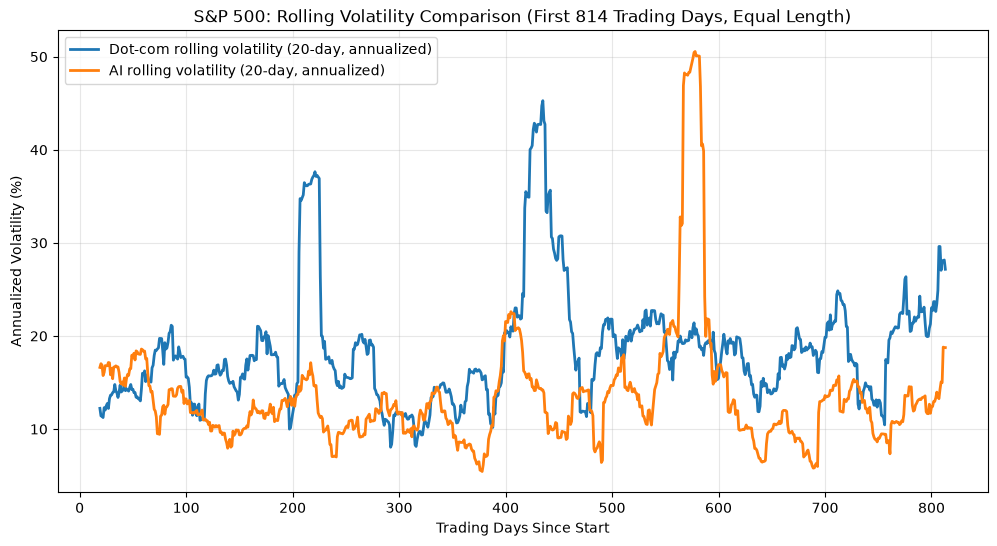

In [12]:
# Calculate 20-day rolling volatility for both eras (equal length, no shift)
dotcom_rolling_vol = pd.Series(dotcom_log_returns_equal).rolling(20).std() * np.sqrt(252)  # annualized
ai_rolling_vol = pd.Series(ai_log_returns_equal).rolling(20).std() * np.sqrt(252)  # annualized

plt.figure(figsize=(12, 6))

plt.plot(dotcom_rolling_vol.values, label="Dot-com rolling volatility (20-day, annualized)", linewidth=2)
plt.plot(ai_rolling_vol.values, label="AI rolling volatility (20-day, annualized)", linewidth=2)

plt.title(f"S&P 500: Rolling Volatility Comparison (First {n_days} Trading Days, Equal Length)")
plt.ylabel("Annualized Volatility (%)")
plt.xlabel("Trading Days Since Start")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

**Key takeaway**: This confirms the kurtosis finding — dot-com had sustained, elevated volatility (a slow-burn panic), while AI has been calm punctuated by a single extreme shock (consistent with fat tails/"earthquake" behavior). AI's overall volatility is lower, but when it spikes, it spikes harder and faster than dot-com ever did, then recovers.

In [13]:
# Rounds out the return-distribution stats above with an annualized growth-rate view
# Take the log of price so a constant growth rate shows up as a straight line, then fit that line
dotcom_close = dotcom["Close"].squeeze()
ai_close = ai["Close"].squeeze()

dotcom_log = np.log(dotcom_close)
ai_log = np.log(ai_close)

# Fit a straight line to each log-price series - the slope is the average daily log-growth rate
# Dot-com is limited to its pre-crash run-up (up to its peak) so the crash doesn't drag down its growth rate
dotcom_log_uprise = dotcom_log.iloc[:dotcom_peak_idx]
dotcom_slope, _ = np.polyfit(np.arange(len(dotcom_log_uprise)), dotcom_log_uprise.to_numpy(), 1)
ai_slope, _ = np.polyfit(np.arange(len(ai_log)), ai_log.to_numpy(), 1)

# Convert daily log-growth rate to an annualized percentage growth rate (252 trading days/year)
dotcom_annual_growth = (np.exp(dotcom_slope * 252) - 1) * 100
ai_annual_growth = (np.exp(ai_slope * 252) - 1) * 100

print(f"Dot-com average annualized growth rate (pre-crash run-up only): {dotcom_annual_growth:.1f}%/year")
print(f"AI average annualized growth rate: {ai_annual_growth:.1f}%/year")

Dot-com average annualized growth rate (pre-crash run-up only): 21.9%/year
AI average annualized growth rate: 19.9%/year


In [14]:
# Worst peak-to-trough decline during the run-up only (same equal-length window as the stats comparison above)
# This measures pullbacks while still climbing - not the eventual dot-com crash, which AI hasn't had yet
dotcom_price_equal = dotcom_norm.to_numpy().ravel()[:n_days]
ai_price_equal = ai_norm.to_numpy().ravel()[:n_days]

def max_drawdown(prices):
    running_max = np.maximum.accumulate(prices)
    drawdown = (prices - running_max) / running_max
    return drawdown.min() * 100  # percentage

dotcom_max_dd = max_drawdown(dotcom_price_equal)
ai_max_dd = max_drawdown(ai_price_equal)

print(f"Dot-com max drawdown during run-up (first {n_days} trading days): {dotcom_max_dd:.1f}%")
print(f"AI max drawdown so far (first {n_days} trading days): {ai_max_dd:.1f}%")

# Trading days from the worst trough back to the prior peak - tests whether AI's shocks actually "snap back" faster
def recovery_time(prices):
    running_max = np.maximum.accumulate(prices)
    drawdown = (prices - running_max) / running_max
    trough_idx = int(np.argmin(drawdown))
    peak_before_trough = running_max[trough_idx]
    recovered = np.where(prices[trough_idx:] >= peak_before_trough)[0]
    return int(recovered[0]) if len(recovered) > 0 else None  # None = not yet recovered

dotcom_recovery = recovery_time(dotcom_price_equal)
ai_recovery = recovery_time(ai_price_equal)

print(f"\nDot-com days to recover from worst drawdown: {dotcom_recovery}")
print(f"AI days to recover from worst drawdown so far: {ai_recovery if ai_recovery is not None else 'not yet recovered'}")

Dot-com max drawdown during run-up (first 814 trading days): -19.3%
AI max drawdown so far (first 814 trading days): -18.9%

Dot-com days to recover from worst drawdown: 59
AI days to recover from worst drawdown so far: 55


**Takeaway:**
- **Similar worst-case drawdown:** Dot-com's worst run-up drawdown (-19.3%) and AI's worst so far (-18.9%) are nearly identical.
- **Despite very different kurtosis:** AI's kurtosis (13.3) is far higher than dot-com's (3.5), yet its sharper individual shock days aren't compounding into a deeper sustained decline.
- **Recovery speed also similar:** Dot-com took 59 trading days to climb back to its prior peak, AI took 55 - essentially the same, so AI's fatter tails aren't making its dips harder to recover from either.

#### 12-Month Holding Period Returns

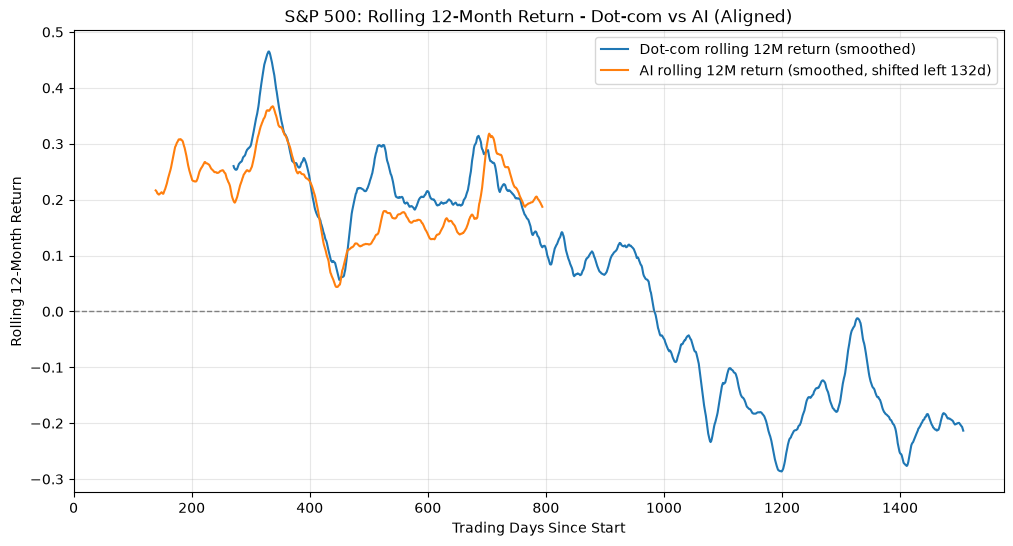

In [15]:
# Rolling 12-month (252 trading day) return for each era, smoothed and aligned with the same shift found earlier
window = 252
dotcom_12m_return = dotcom_norm.squeeze().pct_change(periods=window)
ai_12m_return = ai_norm.squeeze().pct_change(periods=window)

smooth_window = 20
dotcom_12m_smooth = dotcom_12m_return.rolling(smooth_window).mean()
ai_12m_smooth = ai_12m_return.rolling(smooth_window).mean()

x_ai_shifted = np.arange(len(ai_12m_smooth)) - shift

plt.figure(figsize=(12, 6))
plt.plot(dotcom_12m_smooth.values, label="Dot-com rolling 12M return (smoothed)")
plt.plot(x_ai_shifted, ai_12m_smooth.values, label=f"AI rolling 12M return (smoothed, shifted left {shift}d)")
plt.axhline(0, color="gray", linewidth=1, linestyle="--")

plt.title("S&P 500: Rolling 12-Month Return - Dot-com vs AI (Aligned)")
plt.xlabel("Trading Days Since Start")
plt.ylabel("Rolling 12-Month Return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(left=0)
plt.show()

In [16]:
# Best/worst realized 12-month holding return in each era
print(f"Dot-com rolling 12M return: best {dotcom_12m_smooth.max():.1%}, worst {dotcom_12m_smooth.min():.1%}")
print(f"AI rolling 12M return: best {ai_12m_smooth.max():.1%}, worst {ai_12m_smooth.min():.1%}")

# Typical (not just extreme) 12-month return in each era
print(f"\nDot-com rolling 12M return: mean {dotcom_12m_smooth.mean():.1%}, median {dotcom_12m_smooth.median():.1%}")
print(f"AI rolling 12M return: mean {ai_12m_smooth.mean():.1%}, median {ai_12m_smooth.median():.1%}")

# The most recent (latest) trailing 12-month return, i.e. "where things stand right now"
print(f"\nAI rolling 12M return, most recent value: {ai_12m_smooth.iloc[-1]:.1%}")

Dot-com rolling 12M return: best 46.5%, worst -28.6%
AI rolling 12M return: best 36.7%, worst 4.4%

Dot-com rolling 12M return: mean 4.5%, median 8.7%
AI rolling 12M return: mean 20.8%, median 20.6%

AI rolling 12M return, most recent value: 18.7%


**Takeaway:** Dot-com's rolling 12-month return ranged from +46.5% at its best to -28.6% at its worst - the negative end reflects the crash showing up once the rolling window includes it. AI's range so far is +36.7% to +4.4%, meaning every 12-month holding period in the AI era so far has still been positive. AI's peak year was a bit milder than dot-com's best year, but AI hasn't yet had a losing 12-month stretch the way dot-com eventually did. Right now, AI's most recent trailing 12-month return is +18.7% - still solidly positive.

**Personal takeaway:** Even AI's worst 12-month return so far (+4.4%) is still positive, and the current trailing return (+18.7%) is quite high, so for now I'm keeping my holding rather than selling.

So how worried should you be about a potential crash? The AI rally shares the dot-com bubble's overall shape, but shows lower volatility, fatter tails, and a more concentrated, melt-up-style climb. Future parts in this series will zoom out and look at longer-term S&P 500 history to see how much bubbles like this actually matter to a long-term investor.